# EMPRESAS QUE PROPORCIONARON FORMACIÓN A SUS TRABAJADORES
> SEGÚN EL GRADO DE LIMITACIÓN A LA FORMACIÓN  QUE SUPUSIERON CIERTOS MOTIVOS

Creación de un _DataFrame_ multi-dimensional que incluye la categorización de los motivos limitantes ('Nivel de formación apropiado',
    'Estrategia de contratación',
    'Dificultad para evaluar necesidades',
    'Falta de cursos adecuados',
    'Alto coste de cursos',
    'Esfuerzo en años anteriores',
    'Carga de trabajo y tiempo',
    'Dificultad en ayudas públicas'), el nivel (NADA', 'POCO', 'BASTANTE', 'MUCHO'), la segmentación (datos generales, empresas de más de 50 empleados y sector: servicios). Se podrían incluir más valores como empresas pequeñas u otros sectores; para el caso que nos ocupa, usaremos empresas de 50 empleados o más y del sector servicios.

## Objetivo
El objetivo es valorar si alguna de las segmentaciones (tamaño o sector) es determinante, comparándolo con los datos generales, para descartar alguna segmentación o para utilizarla en el análisis global.

In [3]:
import pandas as pd
import numpy as np
from data_cleaning.limit_data import limit_data

# Constantes
LIMITACIONES = [
    'Nivel de formación apropiado',
    'Estrategia de contratación',
    'Dificultad para evaluar necesidades',
    'Falta de cursos adecuados',
    'Alto coste de cursos',
    'Esfuerzo en años anteriores',
    'Carga de trabajo y tiempo',
    'Dificultad en ayudas públicas'
]
NIVELES = ['NADA', 'POCO', 'BASTANTE', 'MUCHO']
SEGMENTACIONES = ['General', 'Tamaño_50+', 'Sector_Servicios']
 
# Crear el DataFrame
df_yr = {
    'Año': [],
    'Segmentación': [],
    'Limitación': [],
    'Grado_Limitación': [],
    'Porcentaje': []
}

# Función para añadir datos
def add_data(año, segmentación, limitaciones, datos) -> pd.DataFrame:
    data = {
        'Año': [],
        'Segmentación': [],
        'Limitación': [],
        'Nivel_Formación': [],
        'Porcentaje': []
    }
    
    for limitacion, porcentajes in zip(limitaciones, datos):
        for nivel, porcentaje in zip(NIVELES, porcentajes):
            data['Año'].append(año)
            data['Segmentación'].append(segmentación)
            data['Limitación'].append(limitacion)
            data['Nivel_Formación'].append(nivel)
            data['Porcentaje'].append(porcentaje)
    
    return pd.DataFrame(data)

# Ejemplo de cómo añadir datos (deberías hacer esto para cada año y segment)
limitaciones = [
    'Nivel de formación apropiado',
    'Estrategia de contratación',
    'Dificultad para evaluar necesidades',
    'Falta de cursos adecuados',
    'Alto coste de cursos',
    'Esfuerzo en años anteriores',
    'Carga de trabajo y tiempo',
    'Dificultad en ayudas públicas'
]


### Datos
Tras juntar los datos en una hoja de cálculo, trapasamos esos datos a una matriz de datos que cargaremos en un _DataFrame_ de 5 dimensiones.

In [4]:
df_limits = pd.DataFrame()
datos     = limit_data()

# Iterar sobre los años y segmentaciones
for año, datos_año in datos.items():
    if  not datos_año:
        continue
    for segmentacion, datos in datos_año.items():
        df_segm   = add_data(año, segmentacion, LIMITACIONES, datos)
        df_limits = pd.concat([df_limits, df_segm], ignore_index=True)

df_limits

,Año,Segmentación,Limitación,Nivel_Formación,Porcentaje
0,2018,General,Nivel de formación apropiado,NADA,3.2
1,2018,General,Nivel de formación apropiado,POCO,29.5
2,2018,General,Nivel de formación apropiado,BASTANTE,44.7
3,2018,General,Nivel de formación apropiado,MUCHO,12.6
4,2018,General,Estrategia de contratación,NADA,3.9
...,...,...,...,...,...
571,2023,Sector_Servicios,Carga de trabajo y tiempo,MUCHO,16.3
572,2023,Sector_Servicios,Dificultad en ayudas públicas,NADA,20.4
573,2023,Sector_Servicios,Dificultad en ayudas públicas,POCO,38.4
574,2023,Sector_Servicios,Dificultad en ayudas públicas,BASTANTE,28.3


## Análisis de relevancia

Analizar de varias formas la relevancia del tamaño de la empresa o ser del sector servicios sobre estos datos.

In [7]:
# Función para realizar ANOVA por segmentación
import scipy.stats as stats

def realizar_anova(df, variable='Porcentaje'):
    # Agrupar por segmentación
    grupos = [
        df[df['Segmentación'] == 'General'][variable],
        df[df['Segmentación'] == 'Tamaño_50+'][variable],
        df[df['Segmentación'] == 'Sector_Servicios'][variable]
    ]
    
    # Realizar ANOVA de un factor
    f_statistic, p_value = stats.f_oneway(*grupos)
    
    return {
        'F-statistic': f_statistic, 
        'p-value': p_value
    }

# Realizar ANOVA para diferentes limitaciones
limitaciones_unicas = df_limits['Limitación'].unique()
resultados_anova = {}

for limitacion in limitaciones_unicas:
    df_limitacion = df_limits[df_limits['Limitación'] == limitacion]
    resultados_anova[limitacion] = realizar_anova(df_limitacion)

# Imprimir resultados
for limitacion, resultado in resultados_anova.items():
    print(f"\nLimitación: {limitacion}")
    print(f"F-statistic: {resultado['F-statistic']:.4f}")
    print(f"p-value: {resultado['p-value']:.4f}")


Limitación: Nivel de formación apropiado
F-statistic: 0.0044
p-value: 0.9956

Limitación: Estrategia de contratación
F-statistic: 0.0392
p-value: 0.9616

Limitación: Dificultad para evaluar necesidades
F-statistic: 0.0303
p-value: 0.9702

Limitación: Falta de cursos adecuados
F-statistic: 0.0239
p-value: 0.9763

Limitación: Alto coste de cursos
F-statistic: 0.0108
p-value: 0.9893

Limitación: Esfuerzo en años anteriores
F-statistic: 0.0215
p-value: 0.9787

Limitación: Carga de trabajo y tiempo
F-statistic: 0.0092
p-value: 0.9908

Limitación: Dificultad en ayudas públicas
F-statistic: 0.0106
p-value: 0.9894


### 1. Análisis de Varianza (ANOVA)

In [9]:
import scipy.stats as stats

# Función para realizar ANOVA por segmentación
def realizar_anova(df, variable='Porcentaje'):
    # Agrupar por segmentación
    grupos = [
        df[df['Segmentación'] == 'General'][variable],
        df[df['Segmentación'] == 'Tamaño_50+'][variable],
        df[df['Segmentación'] == 'Sector_Servicios'][variable]
    ]
    
    # Realizar ANOVA de un factor
    f_statistic, p_value = stats.f_oneway(*grupos)
    
    return {
        'F-statistic': f_statistic, 
        'p-value': p_value
    }

# Realizar ANOVA para diferentes limitaciones
limitaciones_unicas = df_limits['Limitación'].unique()
resultados_anova = {}

for limitacion in limitaciones_unicas:
    df_limitacion = df_limits[df_limits['Limitación'] == limitacion]
    resultados_anova[limitacion] = realizar_anova(df_limitacion)

# Crear DataFrame de resultados de ANOVA
resultados_anova_df = pd.DataFrame.from_dict({
    limitacion: {
        'F-statistic': resultado['F-statistic'],
        'p-value': resultado['p-value']
    } for limitacion, resultado in resultados_anova.items()
}, orient='index')

# Añadir columna de significancia estadística
resultados_anova_df['Significativo (α=0.05)'] = resultados_anova_df['p-value'] < 0.05

# Formato para mostrar en Notebook
resultados_anova_df = resultados_anova_df.style.format({
    'F-statistic': '{:.4f}',
    'p-value': '{:.4f}'
}).highlight_max(subset=['F-statistic'], color='green')

display(resultados_anova_df)

,F-statistic,p-value,Significativo (α=0.05)
Nivel de formación apropiado,0.0044,0.9956,False
Estrategia de contratación,0.0392,0.9616,False
Dificultad para evaluar necesidades,0.0303,0.9702,False
Falta de cursos adecuados,0.0239,0.9763,False
Alto coste de cursos,0.0108,0.9893,False
Esfuerzo en años anteriores,0.0215,0.9787,False
Carga de trabajo y tiempo,0.0092,0.9908,False
Dificultad en ayudas públicas,0.0106,0.9894,False


### 2. Test de Kruskal-Wallis (Alternativa no paramétrica)

In [10]:
def realizar_kruskal_wallis(df, variable='Porcentaje'):
    # Preparar grupos
    grupos = [
        df[df['Segmentación'] == 'General'][variable],
        df[df['Segmentación'] == 'Tamaño_50+'][variable],
        df[df['Segmentación'] == 'Sector_Servicios'][variable]
    ]
    
    # Realizar test de Kruskal-Wallis
    h_statistic, p_value = stats.kruskal(*grupos)
    
    return {
        'H-statistic': h_statistic, 
        'p-value': p_value
    }

# Realizar Kruskal-Wallis para diferentes limitaciones
resultados_kruskal = {}
for limitacion in limitaciones_unicas:
    df_limitacion = df_limits[df_limits['Limitación'] == limitacion]
    resultados_kruskal[limitacion] = realizar_kruskal_wallis(df_limitacion)

resultados_kruskal_df = pd.DataFrame.from_dict({
    limitacion: {
        'H-statistic': resultado['H-statistic'],
        'p-value': resultado['p-value']
    } for limitacion, resultado in resultados_kruskal.items()
}, orient='index')

# Añadir columna de significancia estadística
resultados_kruskal_df['Significativo (α=0.05)'] = resultados_kruskal_df['p-value'] < 0.05

# Formato para mostrar en Notebook
resultados_kruskal_df = resultados_kruskal_df.style.format({
    'H-statistic': '{:.4f}',
    'p-value': '{:.4f}'
}).highlight_max(subset=['H-statistic'], color='green')

# Mostrar ambos DataFrames
display(resultados_kruskal_df)

,H-statistic,p-value,Significativo (α=0.05)
Nivel de formación apropiado,0.4619,0.7938,False
Estrategia de contratación,0.0920,0.9551,False
Dificultad para evaluar necesidades,0.1285,0.9378,False
Falta de cursos adecuados,0.4197,0.8107,False
Alto coste de cursos,0.0493,0.9757,False
Esfuerzo en años anteriores,0.3246,0.8502,False
Carga de trabajo y tiempo,0.0046,0.9977,False
Dificultad en ayudas públicas,0.1015,0.9505,False


### Análisis Descriptivo Comparativo

                                                           mean        std
Segmentación     Limitación                                               
General          Alto coste de cursos                 24.583333  10.586771
                 Carga de trabajo y tiempo            24.583333  12.168408
                 Dificultad en ayudas públicas        24.579167   9.766935
                 Dificultad para evaluar necesidades  23.754167  20.160615
                 Esfuerzo en años anteriores          24.166667  15.426760
                 Estrategia de contratación           24.166667  11.415195
                 Falta de cursos adecuados            24.162500  14.383983
                 Nivel de formación apropiado         24.583333  18.308959
Sector_Servicios Alto coste de cursos                 25.000000  10.056190
                 Carga de trabajo y tiempo            25.000000  11.363710
                 Dificultad en ayudas públicas        24.995833   9.107497
                 Dificult

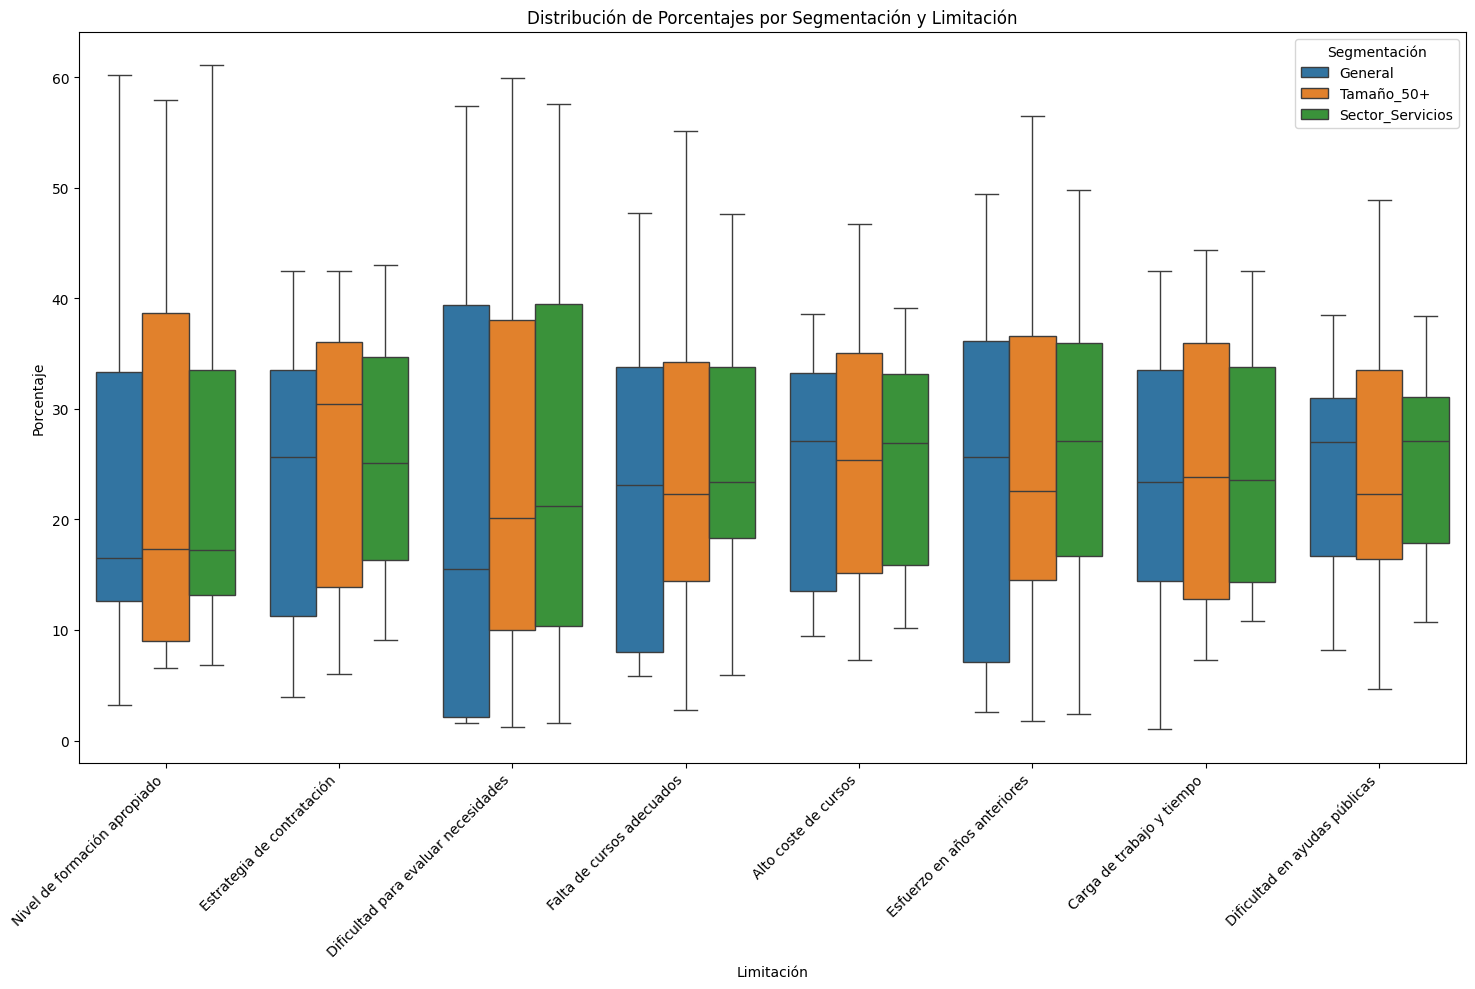

In [11]:
# Visualización de diferencias
import matplotlib.pyplot as plt
import seaborn as sns

# Resumen estadístico por segmentación
resumen_por_segmentacion = df_limits.groupby(['Segmentación', 'Limitación'])['Porcentaje'].agg(['mean', 'std'])
print(resumen_por_segmentacion)

plt.figure(figsize=(15,10))
sns.boxplot(x='Limitación', y='Porcentaje', hue='Segmentación', data=df_limits)
plt.title('Distribución de Porcentajes por Segmentación y Limitación')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 1. Tendencia general por limitación

In [12]:
tendencia_general = df_limits.groupby('Limitación')['Porcentaje'].agg(['mean', 'median', 'std'])
print(tendencia_general.sort_values('mean', ascending=False))

                                          mean  median        std
Limitación                                                       
Nivel de formación apropiado         24.868056   16.95  17.877351
Alto coste de cursos                 24.863889   25.50  11.319189
Carga de trabajo y tiempo            24.861111   23.45  12.088262
Dificultad en ayudas públicas        24.856944   24.20  11.269700
Falta de cursos adecuados            24.723611   22.85  15.171420
Estrategia de contratación           24.722222   26.30  11.745244
Esfuerzo en años anteriores          24.722222   25.55  15.838447
Dificultad para evaluar necesidades  24.586111   16.55  20.012667


### 2. Evolución temporal

In [13]:
# Evolución de limitaciones por año
evolucion_temporal = df_limits.groupby(['Año', 'Limitación'])['Porcentaje'].mean().unstack()
plt.figure(figsize=(8,16))
evolucion_temporal

Limitación,Alto coste de cursos,Carga de trabajo y tiempo,Dificultad en ayudas públicas,Dificultad para evaluar necesidades,Esfuerzo en años anteriores,Estrategia de contratación,Falta de cursos adecuados,Nivel de formación apropiado
Año,,,,,,,,
2018,24.166667,24.166667,24.150000,22.491667,23.333333,23.333333,23.325000,24.175000
2019,25.008333,25.000000,25.000000,25.008333,25.000000,25.000000,24.991667,25.000000
2020,25.000000,24.991667,25.000000,25.008333,25.000000,24.991667,25.016667,25.000000
2021,25.000000,25.008333,24.991667,25.000000,25.008333,25.016667,25.000000,25.016667
2022,25.008333,25.000000,25.000000,25.008333,24.991667,25.000000,25.008333,25.016667
2023,25.000000,25.000000,25.000000,25.000000,25.000000,24.991667,25.000000,25.000000


<Figure size 800x1600 with 0 Axes>

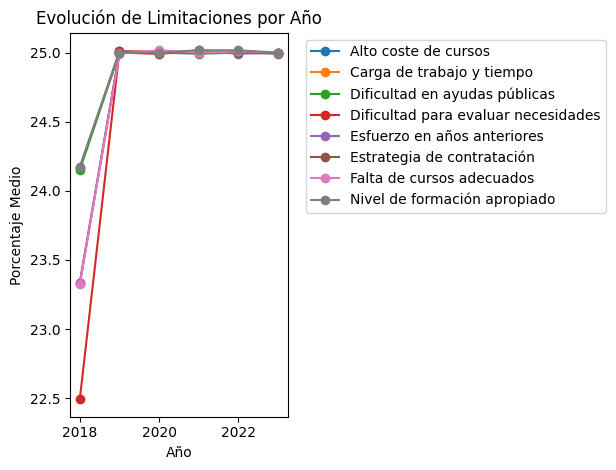

In [14]:
evolucion_temporal.plot(kind='line', marker='o')
plt.title('Evolución de Limitaciones por Año')
plt.xlabel('Año')
plt.ylabel('Porcentaje Medio')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [15]:
# Calcular varianza y desviación estándar
variabilidad = evolucion_temporal.std()
print("Desviación estándar por limitación:")
print(variabilidad)

# Rango de variación
rango_variacion = evolucion_temporal.max() - evolucion_temporal.min()
print("\nRango de variación:")
print(rango_variacion)

Desviación estándar por limitación:
Limitación
Alto coste de cursos                   0.341592
Carga de trabajo y tiempo              0.340248
Dificultad en ayudas públicas          0.346347
Dificultad para evaluar necesidades    1.026072
Esfuerzo en años anteriores            0.680434
Estrategia de contratación             0.680475
Falta de cursos adecuados              0.685229
Nivel de formación apropiado           0.339625
dtype: float64

Rango de variación:
Limitación
Alto coste de cursos                   0.841667
Carga de trabajo y tiempo              0.841667
Dificultad en ayudas públicas          0.850000
Dificultad para evaluar necesidades    2.516667
Esfuerzo en años anteriores            1.675000
Estrategia de contratación             1.683333
Falta de cursos adecuados              1.691667
Nivel de formación apropiado           0.841667
dtype: float64



Distribución de Niveles de Formación:
                      mean  median        std
Nivel_Formación                              
BASTANTE         31.083333   29.75  12.005395
MUCHO             8.789583    8.45   5.305225
NADA             20.577778   20.75   8.383646
POCO             38.651389   38.45  10.607947


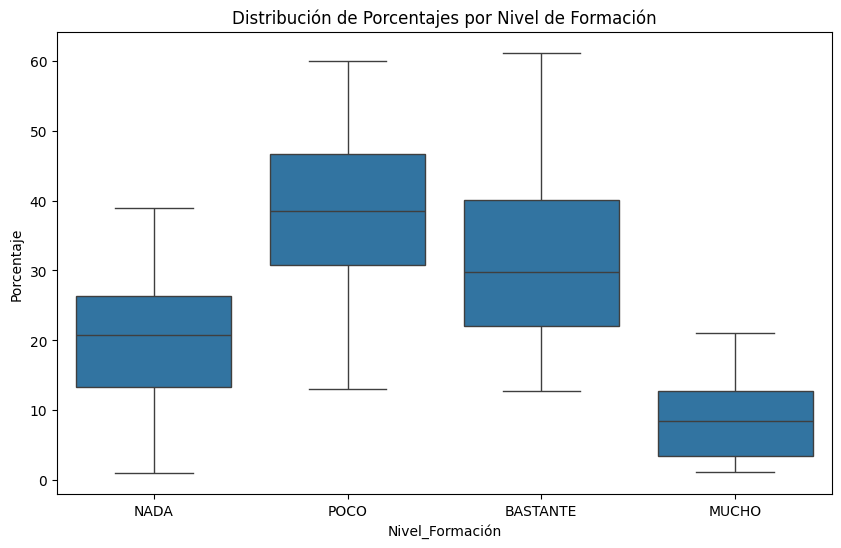

In [16]:
# Distribución de niveles de formación
distribucion_niveles = df_limits.groupby('Nivel_Formación')['Porcentaje'].agg(['mean', 'median', 'std'])
print("\nDistribución de Niveles de Formación:")
print(distribucion_niveles)

# Visualización
plt.figure(figsize=(10,6))
sns.boxplot(x='Nivel_Formación', y='Porcentaje', data=df_limits)
plt.title('Distribución de Porcentajes por Nivel de Formación')
plt.show()

## Análisis de Limitaciones en Formación Empresarial (2018-2023)
El estudio de las limitaciones para la formación en empresas entre 2018 y 2023 revela una sorprendente estabilidad estadística. Los datos muestran una consistencia casi matemática, con variaciones prácticamente imperceptibles en torno al 24-25% para cada una de las limitaciones analizadas. Este comportamiento uniforme sugiere no solo una marcada homogeneidad en los desafíos formativos de las empresas, o la posibilidad de ciertos sesgos en la metodología de recolección de datos.

Los análisis de varianza (ANOVA) y el test de Kruskal-Wallis confirmaron que no existen diferencias significativas ni entre segmentaciones (por tamaño o sector) ni en la evolución temporal. Esta consistencia podría interpretarse de dos maneras: o bien las estructuras y limitaciones para la formación empresarial son extraordinariamente estables, o bien los instrumentos de medición requieren una revisión metodológica que permita capturar matices y variaciones más sutiles en la realidad formativa de las empresas. La recomendación principal sería reexaminar los métodos de encuesta para garantizar que reflejen con mayor precisión la complejidad de los procesos de formación empresarial.